Regina Tamayo León

6 abril 2026

## **Actividad Brain Tumor** ##

**EDA**

In [14]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
df=pd.read_csv("brain_tumor_dataset.csv")
df.head()

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes


<Axes: ylabel='Frequency'>

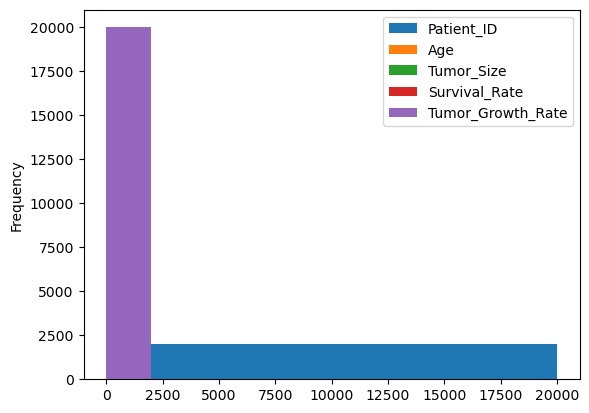

In [5]:
df.plot.hist()

**Bools:**
Gender,
Tumor type,
Radiation Treatment,
Surgery Performed,
Chemotherapy,
Family History,
MRI result,
Follow up required

**Cat:**
Location,
Histology,
Symptom_x

**Cat ord:**
Stage

**Num:**
float: tumor size,
tumor growth rate,
survival rate

int:age

**Histogramas**

*Gráfico pastel*

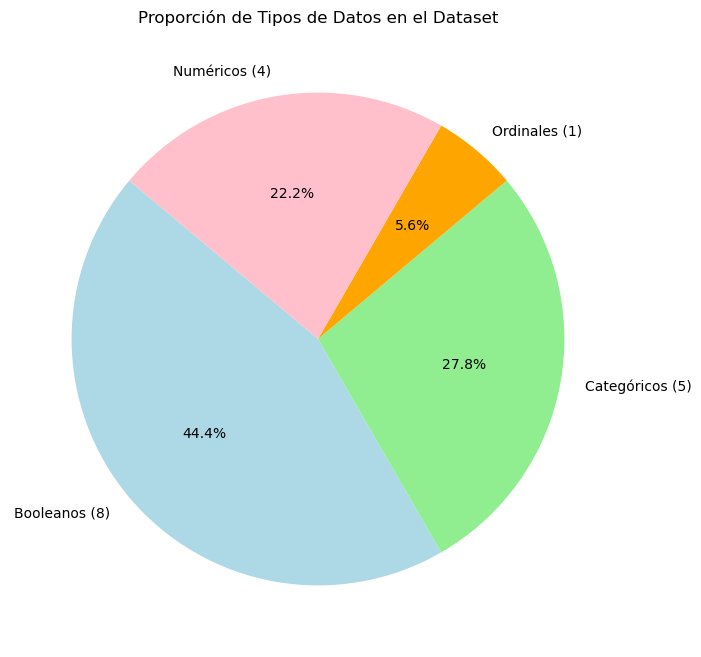

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

bool_cols = ['Gender', 'Tumor_Type', 'Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy', 'Family_History', 'MRI_Result', 'Follow_Up_Required']
cat_cols = ['Location', 'Histology', 'Symptom_1', 'Symptom_2', 'Symptom_3']
ord_cols = ['Stage']
num_cols = ['Tumor_Size', 'Tumor_Growth_Rate', 'Survival_Rate', 'Age']

counts = {'Booleanos (8)': 8, 'Categóricos (5)': 5, 'Ordinales (1)': 1, 'Numéricos (4)': 4}

plt.figure(figsize=(8, 8))
plt.pie(counts.values(), labels=counts.keys(), autopct='%1.1f%%', startangle=140, colors=['lightblue', 'lightgreen', 'orange', 'pink'])
plt.title("Proporción de Tipos de Datos en el Dataset")
plt.show()

*Visualización de booleanos*

/var/folders/wn/wbrpbsz12dl1ks05bpsj29bw0000gn/T/ipykernel_30369/215361949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
/var/folders/wn/wbrpbsz12dl1ks05bpsj29bw0000gn/T/ipykernel_30369/215361949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
/var/folders/wn/wbrpbsz12dl1ks05bpsj29bw0000gn/T/ipykernel_30369/215361949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
/var/folders/wn/wbr

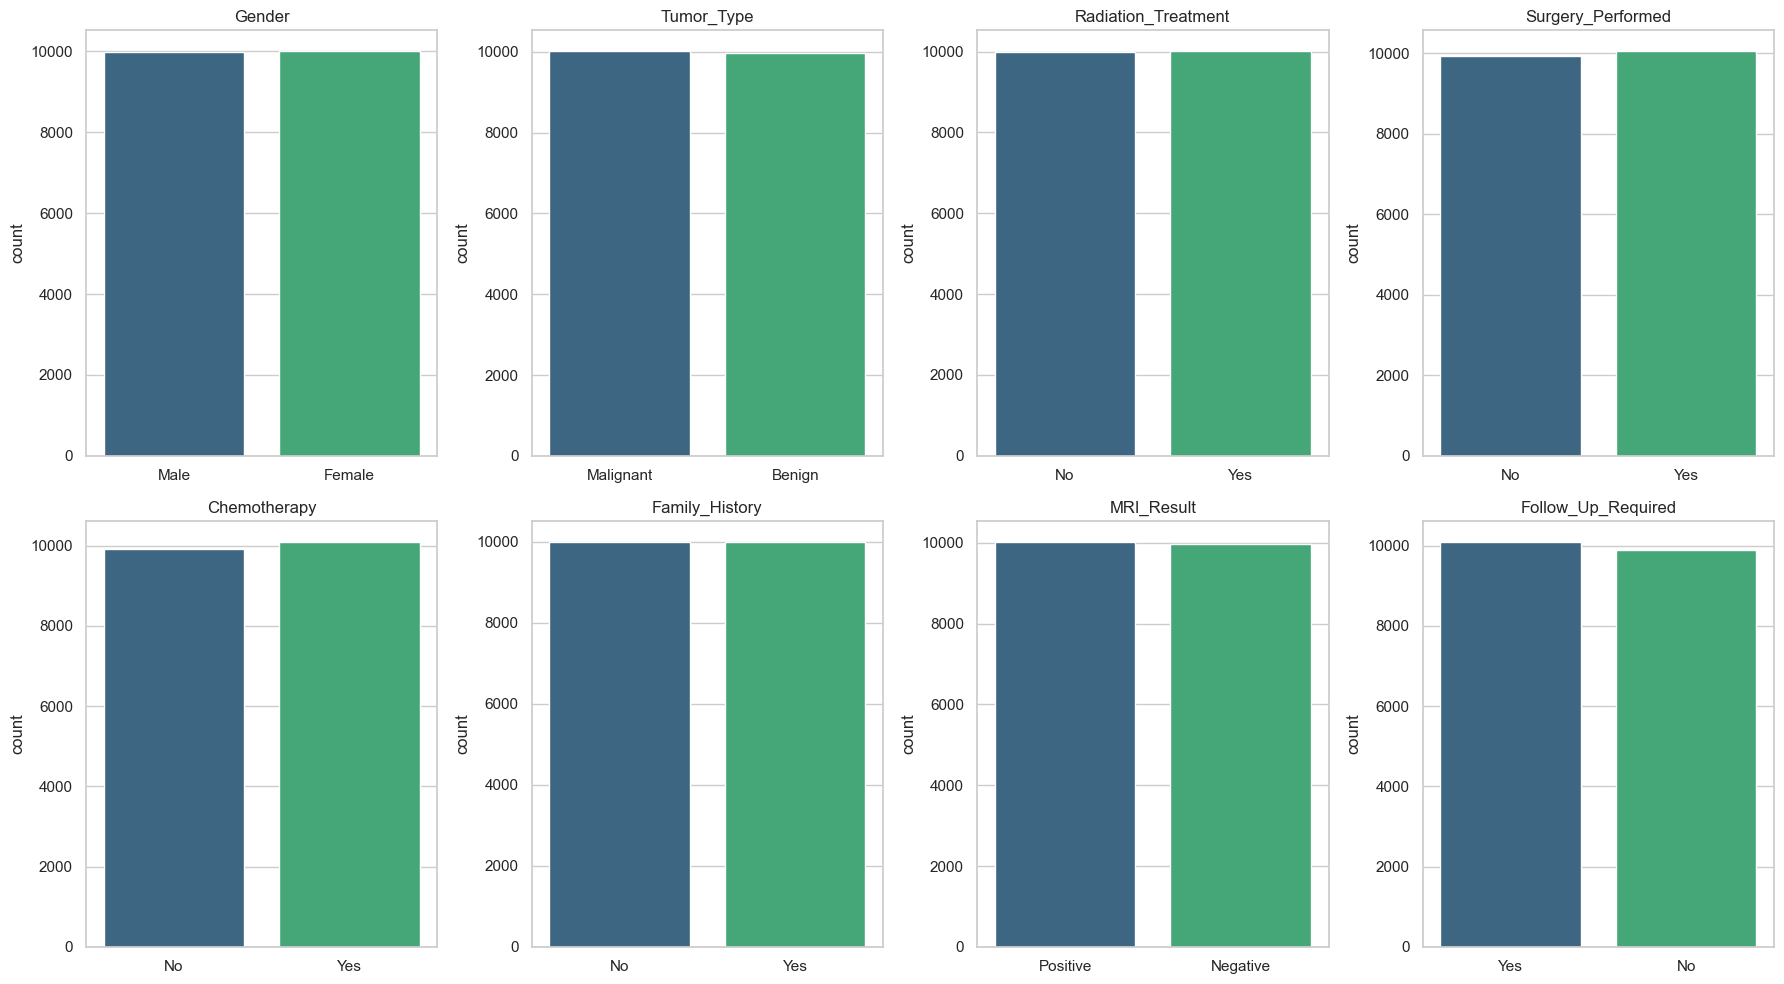

In [7]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(bool_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')
plt.tight_layout()
plt.show()

*Visualización de numéricos*

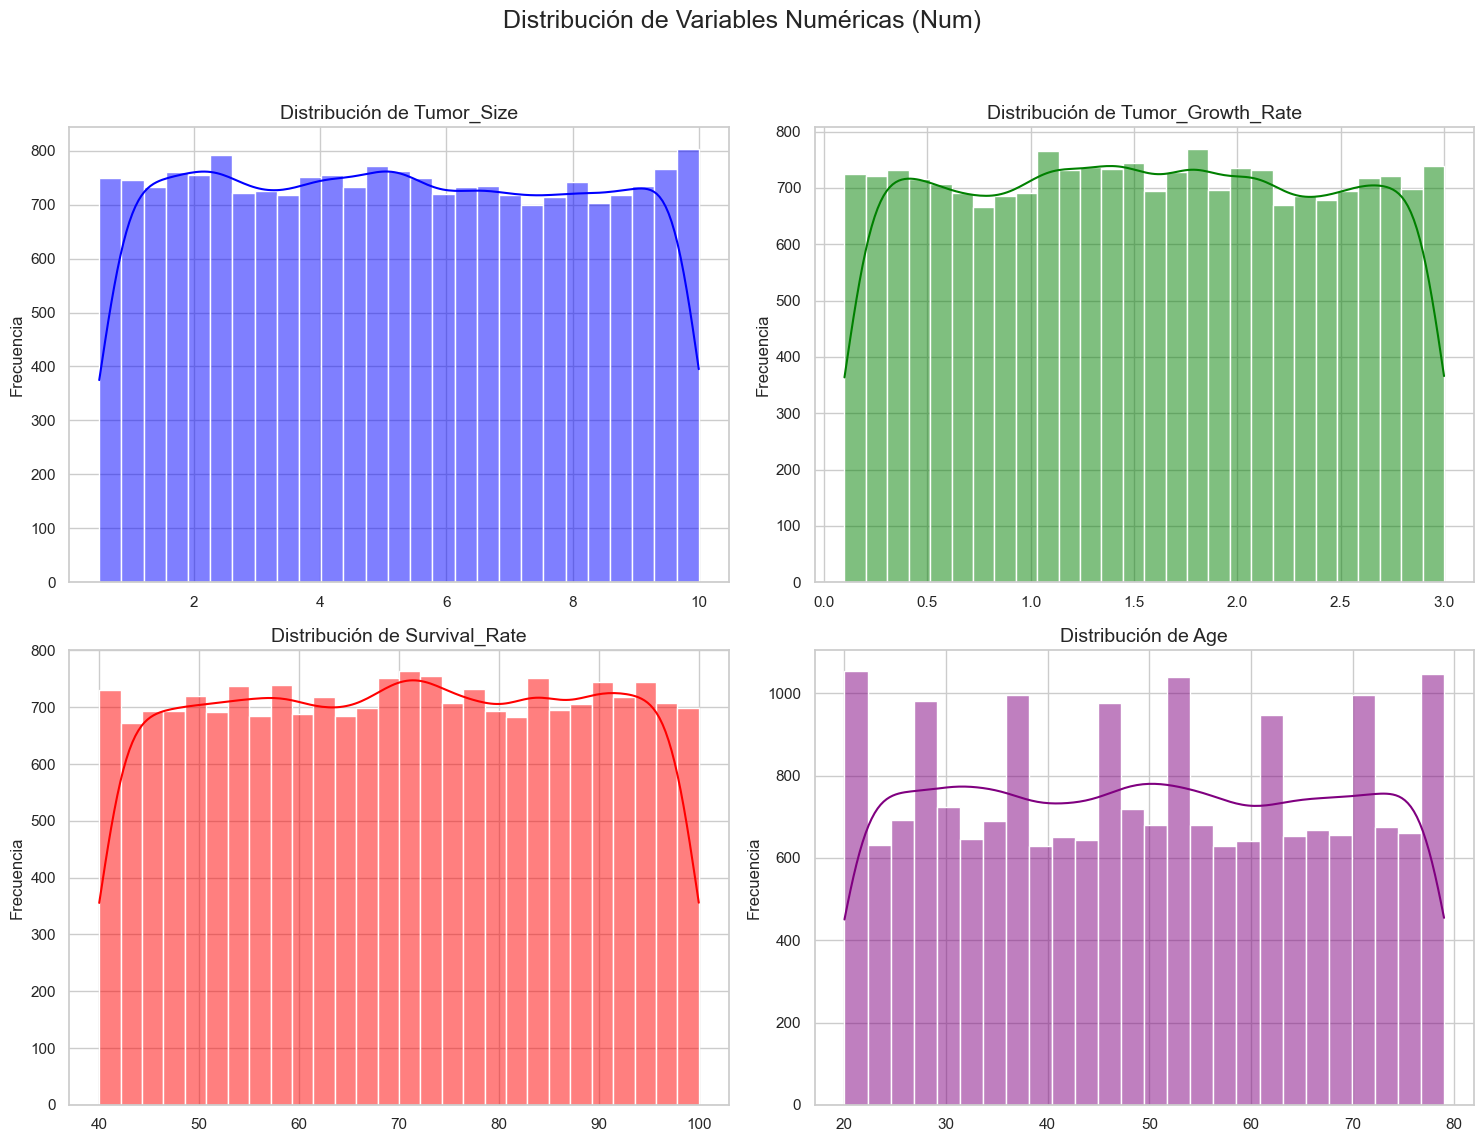

In [8]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Distribución de Variables Numéricas (Num)', fontsize=18)

colors = ['blue', 'green', 'red', 'purple']

for i, col in enumerate(num_cols):
    row, col_idx = divmod(i, 2)
    sns.histplot(df[col], kde=True, ax=axes[row, col_idx], color=colors[i], edgecolor='white')
    axes[row, col_idx].set_title(f'Distribución de {col}', fontsize=14)
    axes[row, col_idx].set_xlabel('')
    axes[row, col_idx].set_ylabel('Frecuencia')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [9]:
((df["Surgery_Performed"] == "Yes") & 
 (df["Radiation_Treatment"] == "Yes") & 
 (df["Chemotherapy"] == "Yes")).sum()

np.int64(2590)

*Definir mis variables (números)*

In [ ]:
y = df['Tumor_Type'].map({'Benign': 0, 'Malignant': 1})
X = df.drop(columns=['Tumor_Type', 'Patient_ID', 'Symptom_1', 'Symptom_2', 'Symptom_3'])


binary_cols = ['Gender', 'Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy', 
               'Family_History', 'MRI_Result', 'Follow_Up_Required']
mappings = {'No': 0, 'Yes': 1, 'Male': 0, 'Female': 1, 'Negative': 0, 'Positive': 1}

for col in binary_cols:
    X[col] = X[col].map(mappings)

# Mapear columna Ordinal
X['Stage'] = X['Stage'].map({'I': 1, 'II': 2, 'III': 3, 'IV': 4})

X = pd.get_dummies(X, columns=['Location', 'Histology'], drop_first=True)

# Escalar los datos numéricos
from sklearn.preprocessing import StandardScaler
num_cols = ['Tumor_Size', 'Tumor_Growth_Rate', 'Survival_Rate', 'Age']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

X.head()

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num_cols", StandardScaler(), num_cols),
        ("ord_cols", OrdinalEncoder(categories=[["I", "II", "III", "IV"]]), ord_cols),
        ("cat_cols", OneHotEncoder(), cat_cols),
        ("bool_cols", OneHotEncoder(), bool_cols)
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline_lineal = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', probability=True, random_state=42))
])

In [ ]:
pipeline_lineal.fit(X_train, y_train)

In [21]:
pipeline_lineal.score(X_train, y_train)

0.5076875

F1=2*(Recall)*(Precission)/(Recall)+(Precission)

Recall=TP/TP+FN

Precission=TP/TP+FP

Mejor score utilizando optimización bayesiana:

In [23]:
pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikit-optimize]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV 

y = df['Tumor_Type'].map({'Benign': 0, 'Malignant': 1})

X = df.drop(columns=['Tumor_Type', 'Patient_ID'])

bool_cols = ['Gender', 'Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy', 
             'Family_History', 'MRI_Result', 'Follow_Up_Required']
cat_cols = ['Location', 'Histology', 'Symptom_1', 'Symptom_2', 'Symptom_3']
ord_cols = ['Stage']
num_cols = ['Tumor_Size', 'Tumor_Growth_Rate', 'Survival_Rate', 'Age']


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("ord", OrdinalEncoder(categories=[["I", "II", "III", "IV"]]), ord_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols + bool_cols)
    ]
)
pipeline_svc = Pipeline([
    ('pre', preprocessor),
    ('svc', SVC(kernel='linear', probability=True, random_state=42))
])

search_space = {
    'svc__C': (1e-3, 1e+3, 'log-uniform') 
}


opt_bayes = BayesSearchCV(
    pipeline_svc,
    search_space,
    n_iter=25,          
    cv=10,              
    scoring='roc_auc',  # Optimizamos el área bajo la curva
    n_jobs=-1,
    random_state=42
)

# Ejecución
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
opt_bayes.fit(X_train, y_train)


print(f"Mejor AUC promedio (CV=10): {opt_bayes.best_score_}")
print(f"Mejor parámetro C: {opt_bayes.best_params_}")


test_score = opt_bayes.score(X_test, y_test)
print(f"AUC en el set de prueba: {test_score}")

In [29]:
from sklearn.metrics import f1_score
import numpy as np

y_pred = np.repeat(1, len(y_test))

f1 = f1_score(y_test, y_pred)

print("F1 score del modelo SVM:", f1)

F1 score del modelo SVM: 0.6673330001665834
